In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [9]:
import os

print("Поточна папка:")
print(os.getcwd())

print("\nФайли в поточній папці:")
for f in os.listdir():
    print(f)

Поточна папка:
d:\2 курс\2 семестр\ІАД\labs\lab1\dm-lab1

Файли в поточній папці:
.git
lab1.ipynb
lab2.ipynb
lab3.ipynb
ml-latest-small
SpotifyFeatures.csv


In [11]:

file_path = 'SpotifyFeatures.csv'

df = pd.read_csv(file_path, encoding='latin1')
print(df.shape)
df.head()

(232725, 18)


,ï»¿genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fÃ©es,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [13]:
print("Розмірність початкового датасету:", df.shape)

print("\nПерші 5 рядків:")
display(df.head())

print("\nСтатистика числових колонок:")
display(df.describe())

Розмірність початкового датасету: (232725, 18)

Перші 5 рядків:


,ï»¿genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fÃ©es,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390



Статистика числових колонок:


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [15]:
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms',
    'popularity'
]

print("Ознаки для кластеризації:")
print(features)

data = df[features].copy()

print("Кількість пропусків у вибраних ознаках:")
display(data.isnull().sum())

print("Розмірність до видалення пропусків:", data.shape)

data = data.dropna()

print("Розмірність після видалення пропусків:", data.shape)

Ознаки для кластеризації:
['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'popularity']
Кількість пропусків у вибраних ознаках:


danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
popularity          0
dtype: int64

Розмірність до видалення пропусків: (232725, 11)
Розмірність після видалення пропусків: (232725, 11)


In [16]:
#стандартизація 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

scaled_df = pd.DataFrame(X_scaled, columns=features, index=data.index)

print("Перші 5 рядків стандартизованих даних:")
display(scaled_df.head())

print("Середні значення після стандартизації:")
display(scaled_df.mean().round(4))

print("Стандартні відхилення після стандартизації:")
display(scaled_df.std().round(4))

Перші 5 рядків стандартизованих даних:


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
0,-0.890935,1.286908,1.290703,-0.367970,0.683376,-0.489819,0.660661,1.380744,1.595607,-1.141368,-2.261007
1,0.191994,0.630249,0.668683,-0.183082,-0.345467,-0.489819,-0.322835,1.388435,1.823253,-0.821867,-2.206031
2,0.585296,-1.669954,-0.718402,-0.455832,1.644570,-0.489819,-0.564927,-0.334212,-0.588326,-0.545298,-2.096080
3,-1.693703,-0.929789,-0.434817,-0.438044,0.942701,-0.489819,-0.587623,-0.876384,1.750597,-0.695295,-2.261007
4,-1.203422,-1.313157,-1.930601,-0.405163,1.638932,-0.083566,-0.065613,-0.249618,0.741433,-1.282184,-2.041104


Середні значення після стандартизації:


danceability       -0.0
energy             -0.0
loudness           -0.0
speechiness         0.0
acousticness        0.0
instrumentalness    0.0
liveness           -0.0
valence            -0.0
tempo              -0.0
duration_ms        -0.0
popularity          0.0
dtype: float64

Стандартні відхилення після стандартизації:


danceability        1.0
energy              1.0
loudness            1.0
speechiness         1.0
acousticness        1.0
instrumentalness    1.0
liveness            1.0
valence             1.0
tempo               1.0
duration_ms         1.0
popularity          1.0
dtype: float64

Стандартизація потрібна тому, що ознаки мають різний масштаб. Наприклад, duration_ms вимірюється в тисячах або сотнях тисяч, а danceability чи energy лежать у межах від 0 до 1. Якщо не стандартизувати дані, K-Means буде надто сильно орієнтуватися на великі за масштабом змінні. Після StandardScaler кожна ознака має середнє близько 0 і стандартне відхилення близько 1, тому всі вони впливають на кластеризацію більш збалансовано.

In [17]:
popular_mask = data['popularity'] >= 85

popular_tracks = data[popular_mask].copy()
popular_tracks_scaled = scaled_df.loc[popular_tracks.index].copy()

print("Розмірність таблиці після фільтрації popularity >= 85:")
print(popular_tracks.shape)

Розмірність таблиці після фільтрації popularity >= 85:
(417, 11)


In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_values = range(2, 16)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

print("Інерції для різних k:")
for k, inertia in zip(k_values, inertias):
    print(f"k = {k}: inertia = {inertia:.2f}")

Інерції для різних k:
k = 2: inertia = 1954726.38
k = 3: inertia = 1661583.45
k = 4: inertia = 1523334.64
k = 5: inertia = 1407101.08
k = 6: inertia = 1331154.06
k = 7: inertia = 1261544.52
k = 8: inertia = 1198102.73
k = 9: inertia = 1147315.97
k = 10: inertia = 1086790.38
k = 11: inertia = 1045854.15
k = 12: inertia = 1009924.50
k = 13: inertia = 978180.56
k = 14: inertia = 954520.30
k = 15: inertia = 933247.02


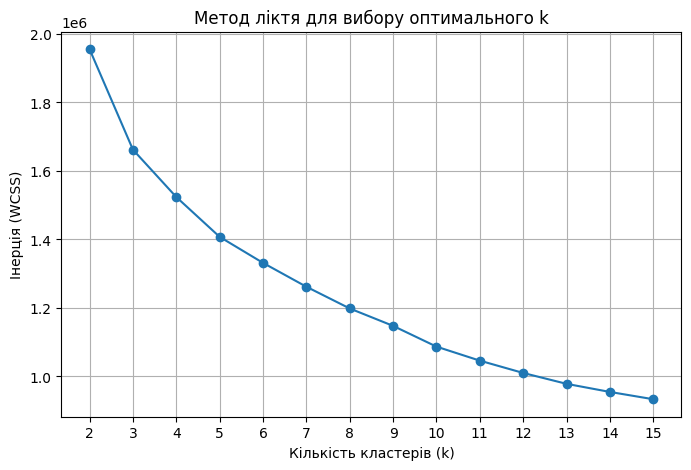

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.title('Метод ліктя для вибору оптимального k')
plt.xlabel('Кількість кластерів (k)')
plt.ylabel('Інерція (WCSS)')
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

Для подальшого аналізу було обрано значення k = 4, оскільки після нього зменшення інерції стає більш плавним, а додавання нових кластерів уже не дає суттєвого покращення якості розбиття.

In [20]:
from sklearn.cluster import KMeans

optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

data['cluster'] = clusters

print("Перші 5 рядків з мітками кластерів:")
display(data.head())

Перші 5 рядків з мітками кластерів:


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity,cluster
0,0.389,0.910,-1.828,0.0525,0.611,0.000,0.3460,0.814,166.969,99373,0,0
1,0.590,0.737,-5.559,0.0868,0.246,0.000,0.1510,0.816,174.003,137373,1,0
2,0.663,0.131,-13.879,0.0362,0.952,0.000,0.1030,0.368,99.488,170267,3,2
3,0.240,0.326,-12.178,0.0395,0.703,0.000,0.0985,0.227,171.758,152427,0,2
4,0.331,0.225,-21.150,0.0456,0.950,0.123,0.2020,0.390,140.576,82625,4,1


In [21]:
cluster_counts = data['cluster'].value_counts().sort_index()

print("Кількість треків у кожному кластері:")
print(cluster_counts)

Кількість треків у кожному кластері:
cluster
0    133030
1     32317
2     57158
3     10220
Name: count, dtype: int64


In [23]:
popular_data = data[data['popularity'] >= 85].copy()

print("Розмірність популярних треків для візуалізації:")
print(popular_data.shape)

print("\nКількість популярних треків у кожному кластері:")
print(popular_data['cluster'].value_counts().sort_index())

Розмірність популярних треків для візуалізації:
(417, 12)

Кількість популярних треків у кожному кластері:
cluster
0    386
2     31
Name: count, dtype: int64


In [24]:
popular_features = popular_data[features].copy()

popular_scaled = scaler.transform(popular_features)

In [25]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2, random_state=42)
popular_pca_2d = pca_2d.fit_transform(popular_scaled)

pca_df = pd.DataFrame(popular_pca_2d, columns=['PC1', 'PC2'], index=popular_data.index)
pca_df['cluster'] = popular_data['cluster'].values

print("Частка поясненої дисперсії двома компонентами:")
print(pca_2d.explained_variance_ratio_)
print("Сумарна пояснена дисперсія:")
print(pca_2d.explained_variance_ratio_.sum())

display(pca_df.head())

Частка поясненої дисперсії двома компонентами:
[0.2749321  0.18553407]
Сумарна пояснена дисперсія:
0.46046617472992724


,PC1,PC2,cluster
9026,1.490707,-0.694703,0
9027,-2.154149,-1.092418,2
9028,0.244933,-0.080095,0
9029,-1.802699,-1.465722,2
9030,-1.673381,-0.327170,0


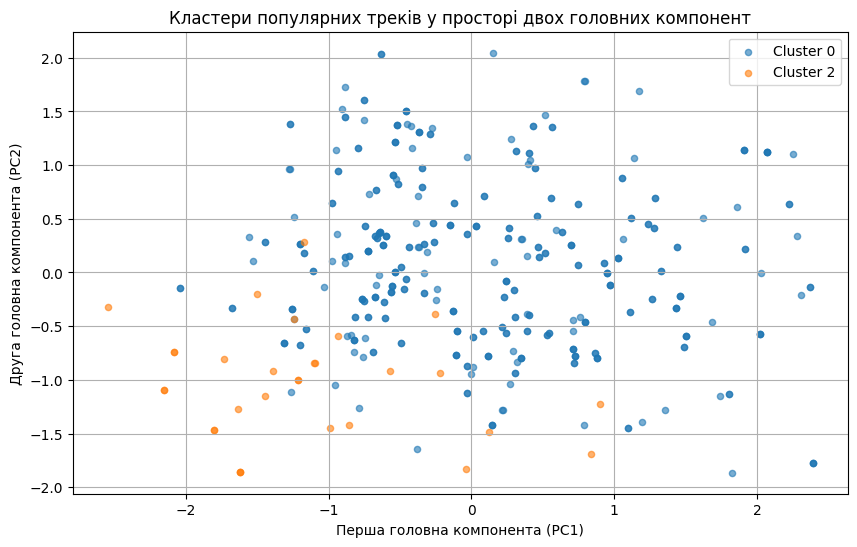

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for cluster_id in sorted(pca_df['cluster'].unique()):
    cluster_points = pca_df[pca_df['cluster'] == cluster_id]
    plt.scatter(
        cluster_points['PC1'],
        cluster_points['PC2'],
        label=f'Cluster {cluster_id}',
        alpha=0.6,
        s=20
    )

plt.title('Кластери популярних треків у просторі двох головних компонент')
plt.xlabel('Перша головна компонента (PC1)')
plt.ylabel('Друга головна компонента (PC2)')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
pca_3d = PCA(n_components=3, random_state=42)
popular_pca_3d = pca_3d.fit_transform(popular_scaled)

pca_3d_df = pd.DataFrame(popular_pca_3d, columns=['PC1', 'PC2', 'PC3'], index=popular_data.index)
pca_3d_df['cluster'] = popular_data['cluster'].values

print("Частка поясненої дисперсії трьома компонентами:")
print(pca_3d.explained_variance_ratio_)
print("Сумарна пояснена дисперсія:")
print(pca_3d.explained_variance_ratio_.sum())

display(pca_3d_df.head())

Частка поясненої дисперсії трьома компонентами:
[0.2749321  0.18553407 0.1656201 ]
Сумарна пояснена дисперсія:
0.6260862786274957


,PC1,PC2,PC3,cluster
9026,1.490707,-0.694703,-0.031063,0
9027,-2.154149,-1.092418,0.681564,2
9028,0.244933,-0.080095,0.108232,0
9029,-1.802699,-1.465722,-0.581003,2
9030,-1.673381,-0.327170,0.689267,0


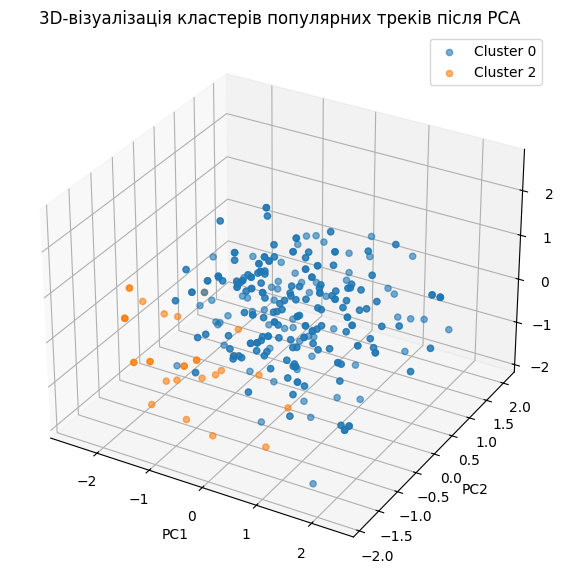

In [28]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for cluster_id in sorted(pca_3d_df['cluster'].unique()):
    cluster_points = pca_3d_df[pca_3d_df['cluster'] == cluster_id]
    ax.scatter(
        cluster_points['PC1'],
        cluster_points['PC2'],
        cluster_points['PC3'],
        label=f'Cluster {cluster_id}',
        alpha=0.6,
        s=20
    )

ax.set_title('3D-візуалізація кластерів популярних треків після PCA')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend()

plt.show()

Побудовані 2D та 3D-графіки показали, що серед треків із popularity >= 85 переважають об’єкти кластерів 0 і 2. Кластер 0 є більш чисельним і розсіяним, що свідчить про більшу різноманітність характеристик треків усередині нього. Кластер 2 є менш чисельним і більш компактним, тобто об’єднує треки зі схожішими ознаками. Між кластерами спостерігається часткове розділення, однак повного відокремлення немає, що є типовим для реальних музичних даних.

In [29]:
cluster_means = data.groupby('cluster')[features].mean()

print("Середні значення ознак у кожному кластері:")
display(cluster_means)

Середні значення ознак у кожному кластері:


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
cluster,,,,,,,,,,,
0,0.614557,0.738879,-6.178513,0.101779,0.120711,0.063954,0.208700,0.551619,124.493808,232171.766481,46.883583
1,0.291617,0.163486,-20.514940,0.048295,0.859527,0.629640,0.160114,0.155464,102.580650,258646.933657,26.144475
2,0.561554,0.394308,-10.836977,0.071564,0.592460,0.098724,0.168745,0.406401,113.769237,227197.194164,39.849715
3,0.561493,0.661623,-12.017876,0.872227,0.790003,0.001431,0.729472,0.414426,98.299789,243464.397358,20.727397


In [30]:
cluster_stats = data.groupby('cluster')[features].agg(['mean', 'std', 'min', 'max'])

print("Розширені статистики по кластерах:")
display(cluster_stats)

Розширені статистики по кластерах:


danceability                             energy                              loudness                          speechiness                          acousticness                             \
                mean       std     min    max      mean       std       min    max       mean       std     min    max        mean       std     min    max         mean       std       min    max   
cluster                                                                                                                                                                                               
0           0.614557  0.154859  0.0617  0.989  0.738879  0.146960  0.158000  0.999  -6.178513  2.306922 -19.116  3.744    0.101779  0.096891  0.0222  0.880     0.120711  0.149680  0.000000  0.961   
1           0.291617  0.143131  0.0569  0.879  0.163486  0.137777  0.000020  0.966 -20.514940  6.216213 -52.457 -3.292    0.048295  0.033475  0.0234  0.798     0.859527  0.209917  0.000001  0.996   
2           0.561554  0.154276  0.0631  0.981  0.394308  0.143437  0.000216  0.973 -10.836977  3.263555 -30.666 -0.575    0.071564  0.083022  0.0222  0.814     0.592460  0.266087  0.000003  0.996   
3           0.561493  0.092943  0.1350  0.944  0.661623  0.222569  0.001410  0.998 -12.017876  4.977173 -32.302 -0.255    0.872227  0.141085  0.0861  0.967     0.790003  0.138847  0.000422  0.995   

        instrumentalness                        liveness                             valence                                tempo                                duration_ms                        \
                    mean       std  min    max      mean       std      min    max      mean       std     min    max        mean        std     min      max           mean            std    min   
cluster                                                                                                                                                                                              
0               0.063954  0.192357  0.0  0.993  0.208700  0.173255  0.00967  1.000  0.551619  0.231224  0.0241  1.000  124.493808  29.714732  39.497  236.799  232171.766481   76719.666846  22800   
1               0.629640  0.367456  0.0  0.999  0.160114  0.137018  0.02000  0.985  0.155464  0.158382  0.0000  1.000  102.580650  30.971104  30.379  236.735  258646.933657  196098.221386  16316   
2               0.098724  0.238330  0.0  0.997  0.168745  0.141911  0.01360  0.996  0.406401  0.232668  0.0000  1.000  113.769237  28.806303  33.792  242.903  227197.194164   90439.492563  15509   
3               0.001431  0.025112  0.0  0.920  0.729472  0.213987  0.03930  0.996  0.414426  0.205059  0.0000  0.979   98.299789  28.062760  32.244  216.312  243464.397358  275480.549643  15387   

                 popularity                      
             max       mean        std min  max  
cluster                                          
0        5488000  46.883583  15.809827   0   99  
1        5552917  26.144475  14.655176   0   75  
2        2514300  39.849715  18.578092   0  100  
3        4791725  20.727397  10.254347   0   72

In [33]:
!pip install seaborn

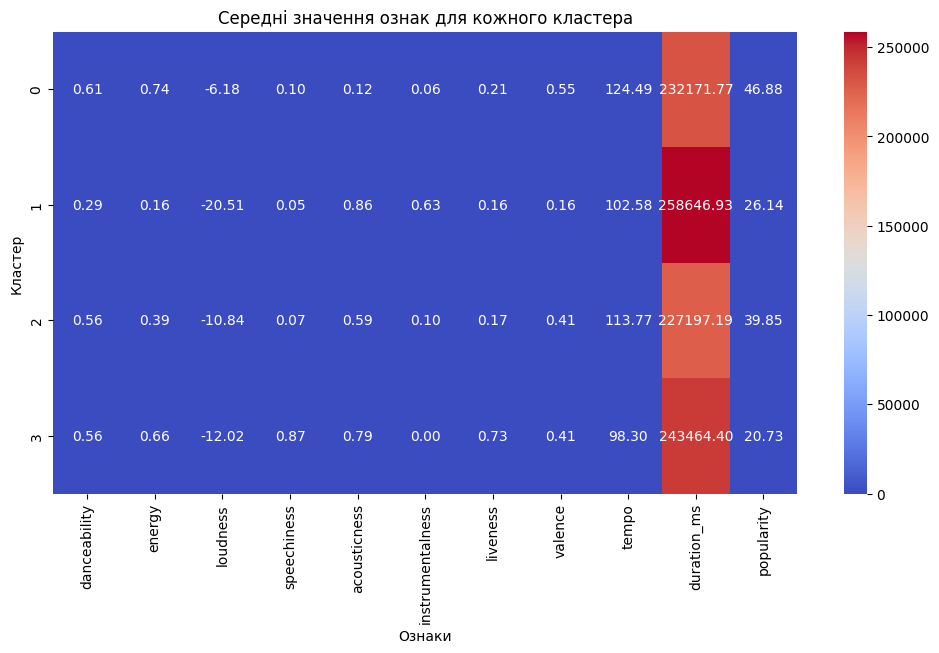

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Середні значення ознак для кожного кластера")
plt.xlabel("Ознаки")
plt.ylabel("Кластер")
plt.show()

In [35]:
popular_cluster_means = popular_data.groupby('cluster')[features].mean()

print("Середні значення ознак для популярних треків по кластерах:")
display(popular_cluster_means)

Середні значення ознак для популярних треків по кластерах:


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
cluster,,,,,,,,,,,
0,0.730342,0.652236,-5.804614,0.130753,0.177873,0.002642,0.174134,0.490626,122.228003,200866.590674,88.437824
2,0.613774,0.388516,-8.703839,0.104752,0.609742,0.005147,0.125100,0.309616,100.720710,206463.354839,88.612903


У результаті аналізу середніх значень ознак для кожного кластера встановлено, що кластер 0 об’єднує найбільш популярні, енергійні та танцювальні треки з вищою гучністю й помірним темпом. Кластер 1 характеризується високою акустичністю та інструментальністю, низькою енергійністю, меншою гучністю і нижчою популярністю, тому його можна інтерпретувати як групу спокійних акустичних або інструментальних композицій. Кластер 2 включає мелодійні та помірно танцювальні треки з вищою акустичністю та середнім рівнем популярності. Кластер 3 вирізняється дуже високим значенням speechiness, що дає підстави трактувати його як групу треків із домінуванням мовленнєвого компоненту, зокрема речитативних або spoken-word композицій. Серед треків із високою популярністю (popularity >= 85) переважають кластери 0 і 2, тобто найбільш популярними виявилися або енергійні танцювальні композиції, або більш м’які мелодійні треки.